                 age workclass        fnlwgt education  education.num  \
count   32561.000000     30725  3.256100e+04     32561   32561.000000   
unique           NaN         8           NaN        16            NaN   
top              NaN   Private           NaN   HS-grad            NaN   
freq             NaN     22696           NaN     10501            NaN   
mean       38.581647       NaN  1.897784e+05       NaN      10.080679   
std        13.640433       NaN  1.055500e+05       NaN       2.572720   
min        17.000000       NaN  1.228500e+04       NaN       1.000000   
25%        28.000000       NaN  1.178270e+05       NaN       9.000000   
50%        37.000000       NaN  1.783560e+05       NaN      10.000000   
75%        48.000000       NaN  2.370510e+05       NaN      12.000000   
max        90.000000       NaN  1.484705e+06       NaN      16.000000   

            marital.status      occupation relationship   race    sex  \
count                32561           30718        

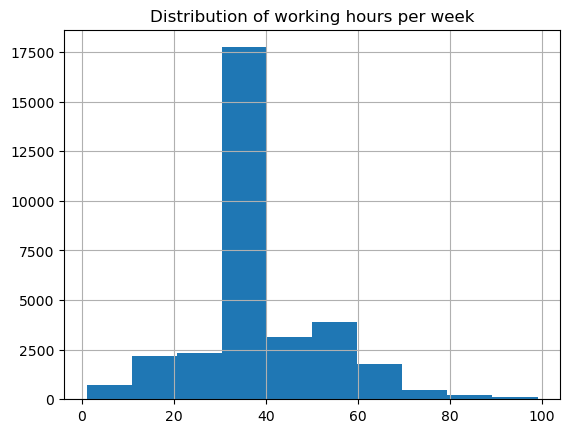

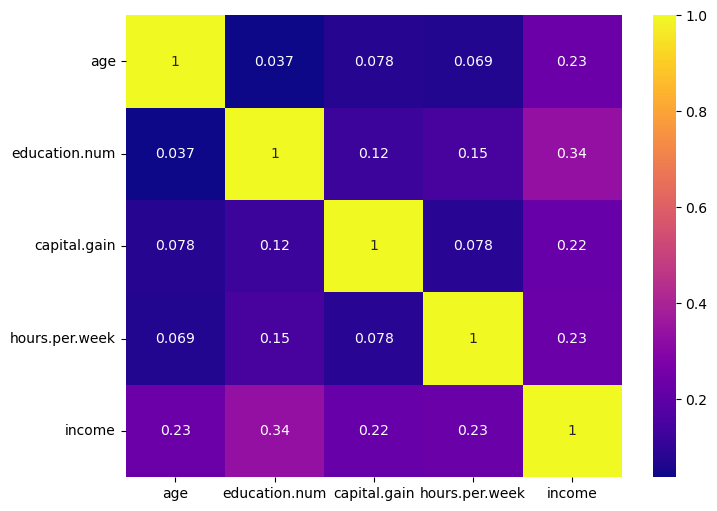

income         0         1
sex                       
Female  0.890539  0.109461
Male    0.694263  0.305737


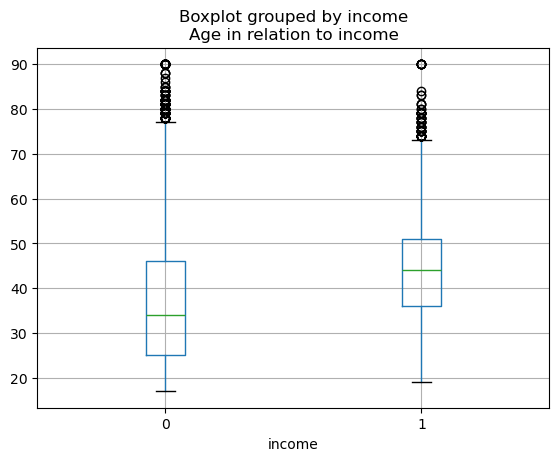

C:\Users\Home\AppData\Local\Temp\ipykernel_33744\2605413099.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[numerical_features]= scaler.fit_transform(X[numerical_features])


Optimization terminated successfully.
         Current function value: 0.337629
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                 income   No. Observations:                30718
Model:                          Logit   Df Residuals:                    30693
Method:                           MLE   Df Model:                           24
Date:                Sun, 23 Nov 2025   Pseudo R-squ.:                  0.3985
Time:                        18:43:55   Log-Likelihood:                -10371.
converged:                       True   LL-Null:                       -17241.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -2.7163      0.

C:\Users\Home\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


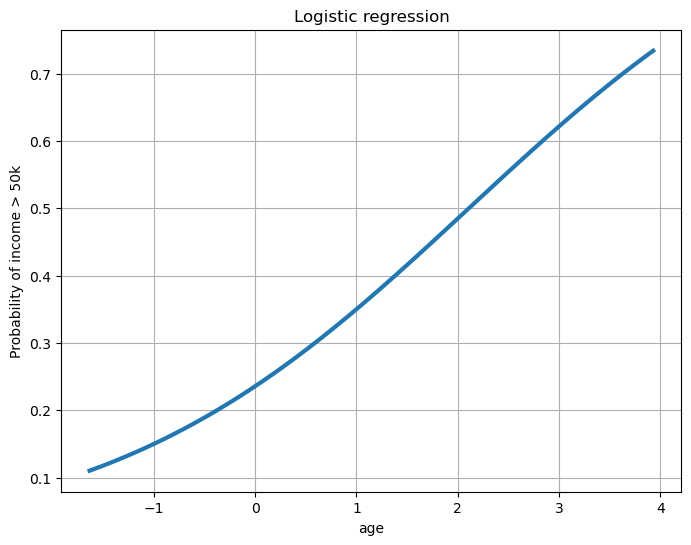

Accuracy: 0.8053385416666666
/nClassification report:,/n               precision    recall  f1-score   support

           0       0.94      0.80      0.86      4639
           1       0.57      0.83      0.68      1505

    accuracy                           0.81      6144
   macro avg       0.75      0.81      0.77      6144
weighted avg       0.85      0.81      0.82      6144

Confusion matrix:/n [[3693  946]
 [ 250 1255]]
Accuracy: 0.85205078125
/nClassification report:,/n               precision    recall  f1-score   support

           0       0.86      0.96      0.91      4639
           1       0.80      0.53      0.64      1505

    accuracy                           0.85      6144
   macro avg       0.83      0.74      0.77      6144
weighted avg       0.85      0.85      0.84      6144

Confusion matrix:/n [[4443  196]
 [ 713  792]]
                                 feature  importance
5      marital.status_Married-civ-spouse    0.244054
2                           capital.g

In [46]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

#Loading the Dataset adultDB.csv
data = pd.read_csv(r"C:\Users\Home\OneDrive\Bureau\Cours EDHEC\Data mining\adultDB.csv", sep=';')

#We convert our target which is 'income' to binary
data['income']=(data['income'].str.strip().str.lower()==">50k").astype(int)

#Summarize individual features
print(data.describe(include="all"))

#Distribution of one variable
data['hours.per.week'].hist()
plt.title("Distribution of working hours per week")
plt.show()

#Heatmap creation
correlation_matrix=data[['age','education.num','capital.gain','hours.per.week','income']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, cmap='plasma', annot=True)
plt.show()

#Distribution between men and women
print(pd.crosstab(data['sex'],data['income'], normalize='index'))

#Relationships between 2 features
data.boxplot(column='age', by='income')
plt.title("Age in relation to income")
plt.show()

#We choose our features and we make a separation between our numerical and categorical features
numerical_features=['age','education.num','capital.gain','hours.per.week']
categorical_features=['marital.status','occupation','sex']

#We remove the rows from the dataset that contain missing values
data=data.dropna(subset=numerical_features+categorical_features)

#We transform each  category contained in our 'categorical_features' into a column of 0 or 1 so that we can make them usable in our models
data_encoded=pd.get_dummies(data, columns=categorical_features, drop_first=True)

#For X, we select the numerical_features and all the encoded columns that we generated from our categorical_features : marital.status, occupation, sex
#We select our target which is 'income'
X= data_encoded[numerical_features+
                [col for col in data_encoded.columns if any(col.startswith(f) for f in categorical_features)]]
Y= data_encoded['income']

#Standardization of our numerical_features in order to improve our model's performance
scaler= StandardScaler()
X[numerical_features]= scaler.fit_transform(X[numerical_features])

#Split our dataset into 20% for the test and 80% for the training
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.2, random_state=42)

#We convert our data to float type in order to ensure compatibility
X = X.astype(float)
Y = Y.astype(float)

#Obtaining the statistical summary of the logistic regression
model = sm.Logit(Y, sm.add_constant(X))
result = model.fit()
print(result.summary())

#Logistic regression with all features
logistic_reg=LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
logistic_reg.fit(X, Y)
print('Intercept:', logistic_reg.intercept_)
print('Coefficients:', logistic_reg.coef_)

#Logistic regression with the feature Age
X_age = X[['age']]
Y_income = Y

log_reg_age=LogisticRegression()
log_reg_age.fit(X_age,Y_income)

age_vals=np.linspace(X_age.min(),X_age.max(), 300).reshape(-1,1)

prob_vals=log_reg_age.predict_proba(age_vals)[:,1]

plt.figure(figsize=(8,6))
plt.plot(age_vals, prob_vals, linewidth=3)
plt.xlabel("age")
plt.ylabel("Probability of income > 50k")
plt.title("Logistic regression")
plt.grid(True)
plt.show()

Y_pred_logregression= logistic_reg.predict(X_test)

#Print our logistic regression's performance score
print("Accuracy:", accuracy_score(Y_test, Y_pred_logregression))
print("/nClassification report:,/n", classification_report(Y_test, Y_pred_logregression))
print("Confusion matrix:/n", confusion_matrix(Y_test, Y_pred_logregression))

#Creation of our Random Forest with its parameters
rf= RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    random_state=42
)

rf.fit(X_train, Y_train)

Y_pred= rf.predict(X_test)

#Print our Random Forest's performance score
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("/nClassification report:,/n", classification_report(Y_test, Y_pred))
print("Confusion matrix:/n", confusion_matrix(Y_test, Y_pred))

#Ranked feature importance from the Random Forest
feature_importance= rf.feature_importances_
feature_names= X.columns

importance_df= pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance',ascending=False)
print(importance_df)